# Subgroup Comparisons
Exploratory profile comparisons: instruction-tuned vs base models, reasoning capability, geographic origin, model families, parameter scale, release date, open-weight vs proprietary, and CFA correlation heatmap.

In [1]:
# Imports
import warnings
from src.reading_data import create_final_dfs
from src.visualizations import *

warnings.filterwarnings("ignore", category=UserWarning)
os.makedirs("../../doc/figs", exist_ok=True)
apply_paper_style()

In [2]:
# Load data
_, _, _, df_B, _, df_metadata, _ = create_final_dfs()


Models excluded (< 200 valid responses), 17 total:
                                       n_valid
model                                         
ThingAI/Quark-270m-Base                      0
google/gemma-3-270m                         14
google/gemma-3-270m-it                      16
EssentialAI/rnj-1                           63
google/gemma-4-31B                          81
Qwen/Qwen3-0.6B                             93
Qwen/Qwen3.5-0.8B-Base                      99
google/gemma-3-1b-pt                       112
ThingAI/Quark-270m-Instruct                121
google/gemma-3-1b-it                       122
google/gemma-2b                            157
mistralai/Mistral-Small-24B-Base-2501      163
Qwen/Qwen3.5-4B-Base                       174
tiiuae/Falcon3-1B-Base                     178
Qwen/Qwen3.5-2B-Base                       192
allenai/OLMo-2-0425-1B                     197
google/gemma-2-2b                          198

Models present before exclusion: 264
Models remaining 

## Instruction-Tuned vs Base Models

In [3]:
IT_BASE_PAIRS = [
    ("Qwen/Qwen3-0.6B-Base",                    "Qwen/Qwen3-0.6B"),
    ("Qwen/Qwen3-8B-Base",                      "openrouter/qwen/qwen3-8b"),
    ("Qwen/Qwen3-14B-Base",                     "deepinfra/Qwen/Qwen3-14B"),
    ("Qwen/Qwen3.5-0.8B-Base",                  "deepinfra/Qwen/Qwen3.5-0.8B"),
    ("Qwen/Qwen3.5-2B-Base",                    "deepinfra/Qwen/Qwen3.5-2B"),
    ("Qwen/Qwen3.5-4B-Base",                    "deepinfra/Qwen/Qwen3.5-4B"),
    ("Qwen/Qwen3.5-9B-Base",                    "deepinfra/Qwen/Qwen3.5-9B"),
    ("Qwen/Qwen3-30B-A3B-Base",                 "deepinfra/Qwen/Qwen3-30B-A3B"),
    ("Qwen/Qwen3.5-35B-A3B-Base",               "deepinfra/Qwen/Qwen3.5-35B-A3B"),
    ("google/gemma-4-E2B",                      "google/gemma-4-E2B-it"),
    ("google/gemma-4-31B",                      "openrouter/google/gemma-4-31b-it"),
    ("google/gemma-3-4b-pt",                    "deepinfra/google/gemma-3-4b-it"),
    ("google/gemma-2-2b",                       "google/gemma-2-2b-it"),
    ("google/gemma-2-27b",                      "openrouter/google/gemma-2-27b-it"),
    ("google/gemma-2b",                         "google/gemma-2b-it"),
    ("google/gemma-3-1b-pt",                    "google/gemma-3-1b-it"),
    ("google/gemma-3-270m",                     "google/gemma-3-270m-it"),
    ("meta-llama/Llama-3.1-8B",                 "deepinfra/meta-llama/Meta-Llama-3.1-8B-Instruct"),
    ("meta-llama/Llama-3.2-1B",                 "meta-llama/Llama-3.2-1B-Instruct"),
    ("meta-llama/Llama-3.2-3B",                 "meta-llama/Llama-3.2-3B-Instruct"),
    ("tiiuae/Falcon3-1B-Base",                  "tiiuae/Falcon3-1B-Instruct"),
    ("tiiuae/Falcon3-3B-Base",                  "tiiuae/Falcon3-3B-Instruct"),
    ("allenai/OLMo-2-1124-13B",                 "allenai/OLMo-2-1124-13B-Instruct"),
    ("allenai/OLMo-2-0425-1B",                  "allenai/OLMo-2-0425-1B-Instruct"),
    ("allenai/OLMo-2-1124-7B",                  "allenai/OLMo-2-1124-7B-Instruct"),
    ("ThingAI/Quark-270m-Base",                 "ThingAI/Quark-270m-Instruct"),
    ("EssentialAI/rnj-1",                       "openrouter/essentialai/rnj-1-instruct"),
    ("ibm-granite/granite-4.0-h-micro-base",    "openrouter/ibm-granite/granite-4.0-h-micro"),
    ("mistralai/Mistral-7B-v0.1",               "openrouter/mistralai/mistral-7b-instruct-v0.1"),
    ("mistralai/Ministral-3-14B-Base-2512",     "openrouter/mistralai/ministral-14b-2512"),
    ("mistralai/Ministral-3-8B-Base-2512",      "openrouter/mistralai/ministral-8b-2512"),
    ("mistralai/Ministral-3-3B-Base-2512",      "openrouter/mistralai/ministral-3b-2512"),
    ("mistralai/Mistral-Nemo-Base-2407",        "deepinfra/mistralai/Mistral-Nemo-Instruct-2407"),
    ("mistralai/Mistral-Small-24B-Base-2501",   "deepinfra/mistralai/Mistral-Small-24B-Instruct-2501"),
]

In [4]:
# Base vs IT models
df_pairs, stats_it_base = paired_ttest_base_vs_it(df_B, df_metadata, IT_BASE_PAIRS, cols=OCEAN_COLS)

Missing pair: Qwen/Qwen3-0.6B-Base vs Qwen/Qwen3-0.6B
Missing pair: Qwen/Qwen3.5-0.8B-Base vs deepinfra/Qwen/Qwen3.5-0.8B
Missing pair: Qwen/Qwen3.5-2B-Base vs deepinfra/Qwen/Qwen3.5-2B
Missing pair: Qwen/Qwen3.5-4B-Base vs deepinfra/Qwen/Qwen3.5-4B
Missing pair: google/gemma-4-31B vs openrouter/google/gemma-4-31b-it
Missing pair: google/gemma-2-2b vs google/gemma-2-2b-it
Missing pair: google/gemma-2b vs google/gemma-2b-it
Missing pair: google/gemma-3-1b-pt vs google/gemma-3-1b-it
Missing pair: google/gemma-3-270m vs google/gemma-3-270m-it
Missing pair: tiiuae/Falcon3-1B-Base vs tiiuae/Falcon3-1B-Instruct
Missing pair: allenai/OLMo-2-0425-1B vs allenai/OLMo-2-0425-1B-Instruct
Missing pair: ThingAI/Quark-270m-Base vs ThingAI/Quark-270m-Instruct
Missing pair: EssentialAI/rnj-1 vs openrouter/essentialai/rnj-1-instruct
Missing pair: mistralai/Mistral-Small-24B-Base-2501 vs deepinfra/mistralai/Mistral-Small-24B-Instruct-2501


=== Per-pair OCEAN differences (IT − Base) ===

                

In [5]:
print("=== Paired differences (IT − Base) ===")
print(stats_it_base)

=== Paired differences (IT − Base) ===
               trait  mean_diff  sd_diff      t        p
0           Openness       0.12     0.75  0.686  0.50087
1  Conscientiousness       0.44     0.59  3.350  0.00336
2       Extraversion       0.24     0.64  1.656  0.11406
3      Agreeableness       0.57     0.58  4.399  0.00031
4        Neuroticism      -0.47     0.54 -3.912  0.00094


## Reasoning vs Non-Reasoning

In [6]:
# Reasoning vs non-reasoning models
REASONING_COL = "Reasoning"

df_reas = df_metadata.dropna(subset=[REASONING_COL] + OCEAN_COLS).copy()
df_reas[REASONING_COL] = df_reas[REASONING_COL].astype(str).str.strip().str.upper()
df_reas = df_reas[df_reas[REASONING_COL].isin(["TRUE", "FALSE"])]

stats_reas = bonferroni_ttest(df_reas, REASONING_COL, cols=OCEAN_COLS)

print(stats_reas.to_string(index=False))
print_group_stats(df_reas, REASONING_COL)

            trait group1 group2      t  p_bonferroni sig
         Openness  FALSE   TRUE -2.314        0.1114  ns
Conscientiousness  FALSE   TRUE -5.650        0.0000 ***
     Extraversion  FALSE   TRUE -0.951        1.0000  ns
    Agreeableness  FALSE   TRUE -5.089        0.0000 ***
      Neuroticism  FALSE   TRUE  9.694        0.0000 ***

───────────────────────────────────────────────────────
Mean & SD by Reasoning
───────────────────────────────────────────────────────

  [FALSE]  n=155
    Openness                 : mean=3.671  sd=0.424
    Conscientiousness        : mean=3.908  sd=0.529
    Extraversion             : mean=3.649  sd=0.417
    Agreeableness            : mean=3.901  sd=0.491
    Neuroticism              : mean=2.290  sd=0.567

  [TRUE]  n=92
    Openness                 : mean=3.870  sd=0.760
    Conscientiousness        : mean=4.315  sd=0.558
    Extraversion             : mean=3.709  sd=0.507
    Agreeableness            : mean=4.238  sd=0.512
    Neuroticism     

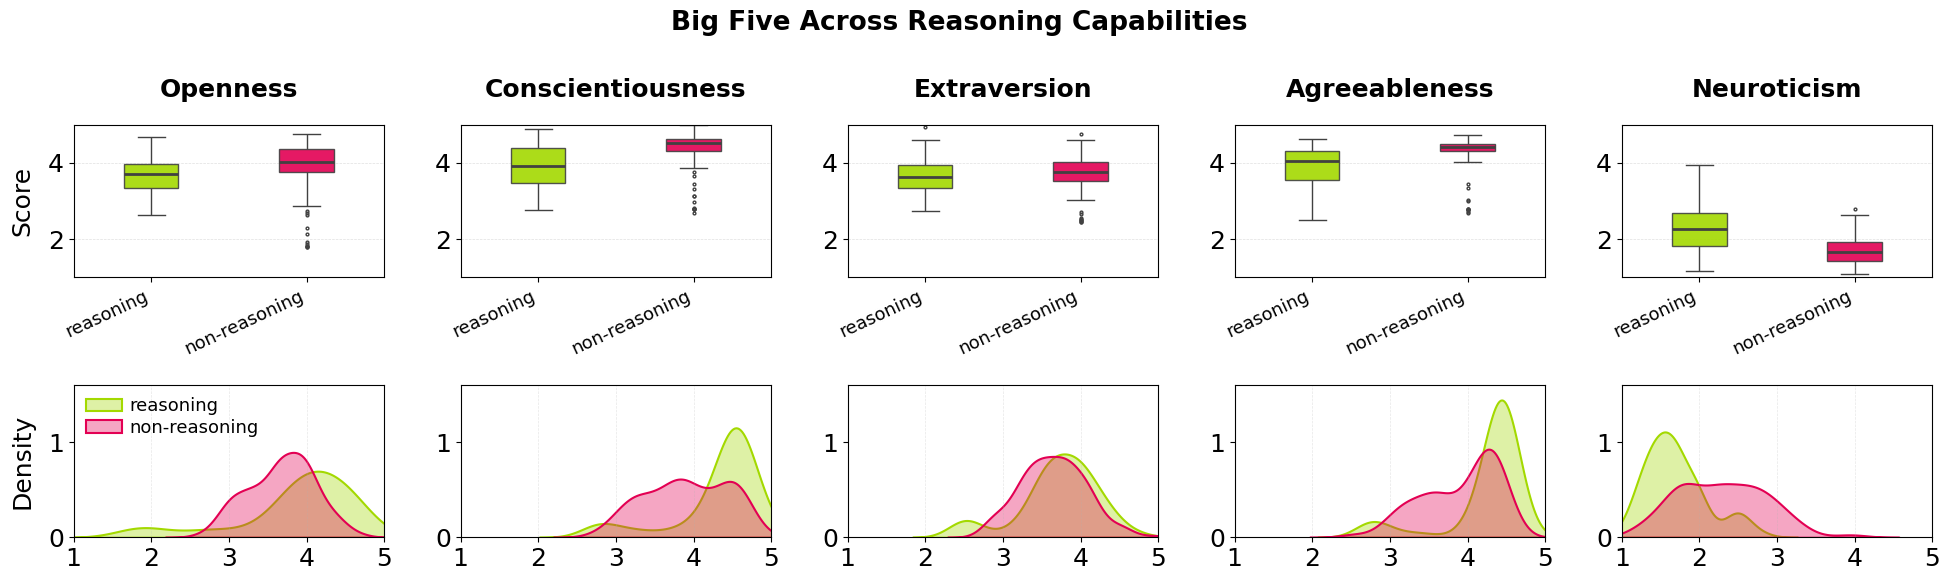

In [7]:
# Plotting
fig = plot_binary_comparison(
    df_reas,
    group_col=REASONING_COL,
    title="Big Five Across Reasoning Capabilities",
    palette=BINARY_PAL_GREEN_RED,
    order=["TRUE", "FALSE"],
    display_labels={
        "TRUE": "reasoning",
        "FALSE": "non-reasoning",
    },
    stats_df=stats_reas,
    cols=OCEAN_COLS,
    save_path="../../doc/figs/fig_reasoning.pdf",
    t_test=False
)
plt.show()

## Geographic Origin

In [8]:
# Country of origin
df_metadata["Country"] = df_metadata["Country"].replace({
    "china": "China", "france": "France", "US": "US",
})

country_counts = df_metadata["Country"].value_counts()
valid_countries = country_counts[country_counts > 5].index

df_ctry = (
    df_metadata[df_metadata["Country"].isin(valid_countries)]
    .dropna(subset=["Country"] + OCEAN_COLS)
)
ctry_order = (
    df_ctry.groupby("Country")["Openness"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

print_group_stats(df_ctry, "Country")


───────────────────────────────────────────────────────
Mean & SD by Country
───────────────────────────────────────────────────────

  [China]  n=97
    Openness                 : mean=3.726  sd=0.680
    Conscientiousness        : mean=4.140  sd=0.571
    Extraversion             : mean=3.701  sd=0.484
    Agreeableness            : mean=4.139  sd=0.520
    Neuroticism              : mean=1.870  sd=0.531

  [France]  n=25
    Openness                 : mean=3.673  sd=0.418
    Conscientiousness        : mean=3.661  sd=0.489
    Extraversion             : mean=3.607  sd=0.385
    Agreeableness            : mean=3.691  sd=0.517
    Neuroticism              : mean=2.610  sd=0.424

  [US]  n=113
    Openness                 : mean=3.801  sd=0.524
    Conscientiousness        : mean=4.111  sd=0.566
    Extraversion             : mean=3.676  sd=0.442
    Agreeableness            : mean=4.029  sd=0.496
    Neuroticism              : mean=2.093  sd=0.577


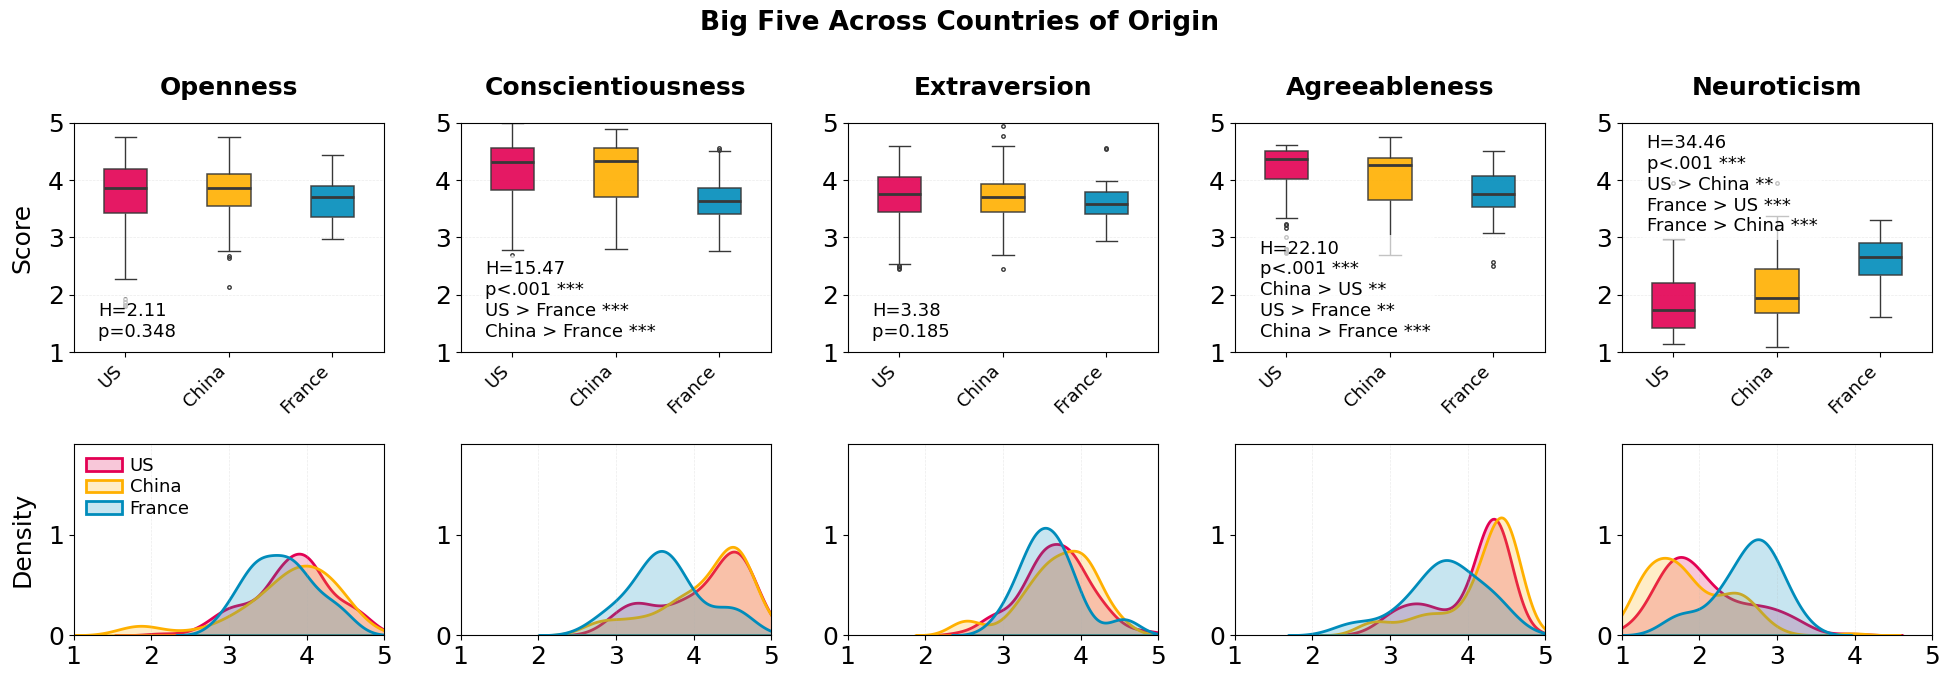

In [9]:
# Plotting
fig = plot_multigroup_comparison(
    df_ctry,
    group_col="Country",
    title="Big Five Across Countries of Origin",
    palette=sns.color_palette(TRI_COLOR, df_ctry["Country"].nunique()),
    order=ctry_order,
    cols=OCEAN_COLS,
    save_path="../../doc/figs/fig_countries.pdf",
)
plt.show()

## Model Family Profiles

In [10]:
# Model family
MIN_MODELS = 5

df_fam_base  = df_metadata.dropna(subset=["Family"] + OCEAN_COLS)
family_counts = df_fam_base["Family"].value_counts()
keep_families = family_counts[family_counts >= MIN_MODELS].index.tolist()

df_family = df_fam_base.copy()
df_family["FamilyGrouped"] = np.where(
    df_family["Family"].isin(keep_families),
    df_family["Family"],
    "other",
)

family_order = (
    df_family[df_family["FamilyGrouped"] != "other"]
    .groupby("FamilyGrouped")["Openness"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
) + ["other"]

df_family["FamilyGroupedClean"] = (
    df_family["FamilyGrouped"]
    .map(FAMILY_LABELS)
    .fillna(df_family["FamilyGrouped"])
)

print(df_family["FamilyGrouped"].value_counts())
# print_group_stats(df_family, "FamilyGrouped")

FamilyGrouped
other       58
qwen        46
mistral     25
gpt         21
llama       14
glm         12
gemma       11
deepseek    10
grok        10
claude       9
seed         7
gemini       7
olmo         6
minimax      6
kimi         5
Name: count, dtype: int64


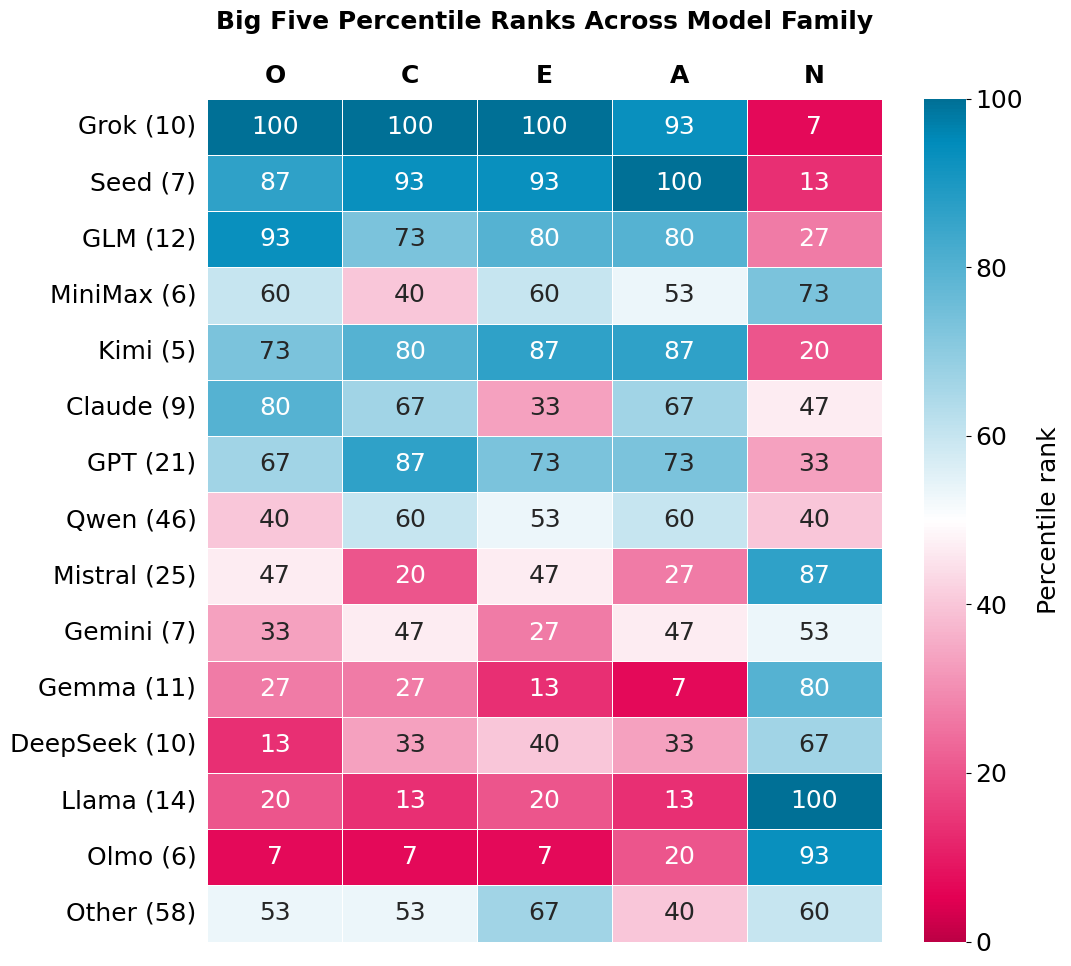

In [11]:
# Plotting
fig = plot_family_heatmap_percentile(
    df_family,
    group_col="FamilyGrouped",
    order=family_order,
    title="Big Five Percentile Ranks Across Model Family",
    save_path="../../doc/figs/fig_heatmap_families_percentile.pdf",
    figsize=(11,10)
)
plt.show()

In [12]:
# GIF animation of model families
MIN_MODELS = 3

df_fam_base  = df_metadata.dropna(subset=["Family"] + OCEAN_COLS)
family_counts = df_fam_base["Family"].value_counts()
keep_families = family_counts[family_counts >= MIN_MODELS].index.tolist()

df_family = df_fam_base.copy()
df_family["FamilyGrouped"] = np.where(
    df_family["Family"].isin(keep_families),
    df_family["Family"],
    "other",
)

family_order = (
    df_family[df_family["FamilyGrouped"] != "other"]
    .groupby("FamilyGrouped")["Openness"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
) + ["other"]

TRAIT_ORDER = [
    "Openness",
    "Conscientiousness",
    "Extraversion",
    "Agreeableness",
    "Neuroticism",
]

PRIORITY = ["gpt", "claude", "gemini", "qwen", "minimax", "mimo", "trinity",
            "o-series", "gpt-oss", "grok", "seed", "glm", "kimi", "nemotron",
            "mistral", "granite", "deepseek",
            "llama", "gemma", "falcon", "other"]

all_families = df_family["FamilyGrouped"].unique().tolist()

family_order = [f for f in PRIORITY if f in all_families]

make_all_plots(
    df_family=df_family,
    family_order=family_order,
    trait_order=TRAIT_ORDER,
    family_labels=FAMILY_LABELS,
    out_dir="../../doc/figs/gif/all",
    gif_path="../../doc/figs/gif/all.gif",
    gif_duration_ms=1400,
)


Done — 21 PNGs + GIF


## Parameter Scale

In [13]:
# Size group comparison
SIZE_ORDER = ["small (<10B)", "medium (10–100B)", "large (>100B)"]
df_sz = df_metadata.dropna(subset=["Size"] + OCEAN_COLS)
sz_present = [s for s in SIZE_ORDER if s in df_sz["Size"].values]
print_group_stats(df_sz, "Size")


───────────────────────────────────────────────────────
Mean & SD by Size
───────────────────────────────────────────────────────

  [large]  n=38
    Openness                 : mean=3.787  sd=0.577
    Conscientiousness        : mean=4.190  sd=0.472
    Extraversion             : mean=3.805  sd=0.469
    Agreeableness            : mean=4.197  sd=0.437
    Neuroticism              : mean=1.866  sd=0.444

  [medium]  n=56
    Openness                 : mean=3.514  sd=0.644
    Conscientiousness        : mean=3.809  sd=0.589
    Extraversion             : mean=3.566  sd=0.477
    Agreeableness            : mean=3.857  sd=0.530
    Neuroticism              : mean=2.291  sd=0.551

  [small]  n=44
    Openness                 : mean=3.410  sd=0.412
    Conscientiousness        : mean=3.527  sd=0.433
    Extraversion             : mean=3.354  sd=0.334
    Agreeableness            : mean=3.517  sd=0.472
    Neuroticism              : mean=2.658  sd=0.558

  [undisclosed]  n=109
    Openness 

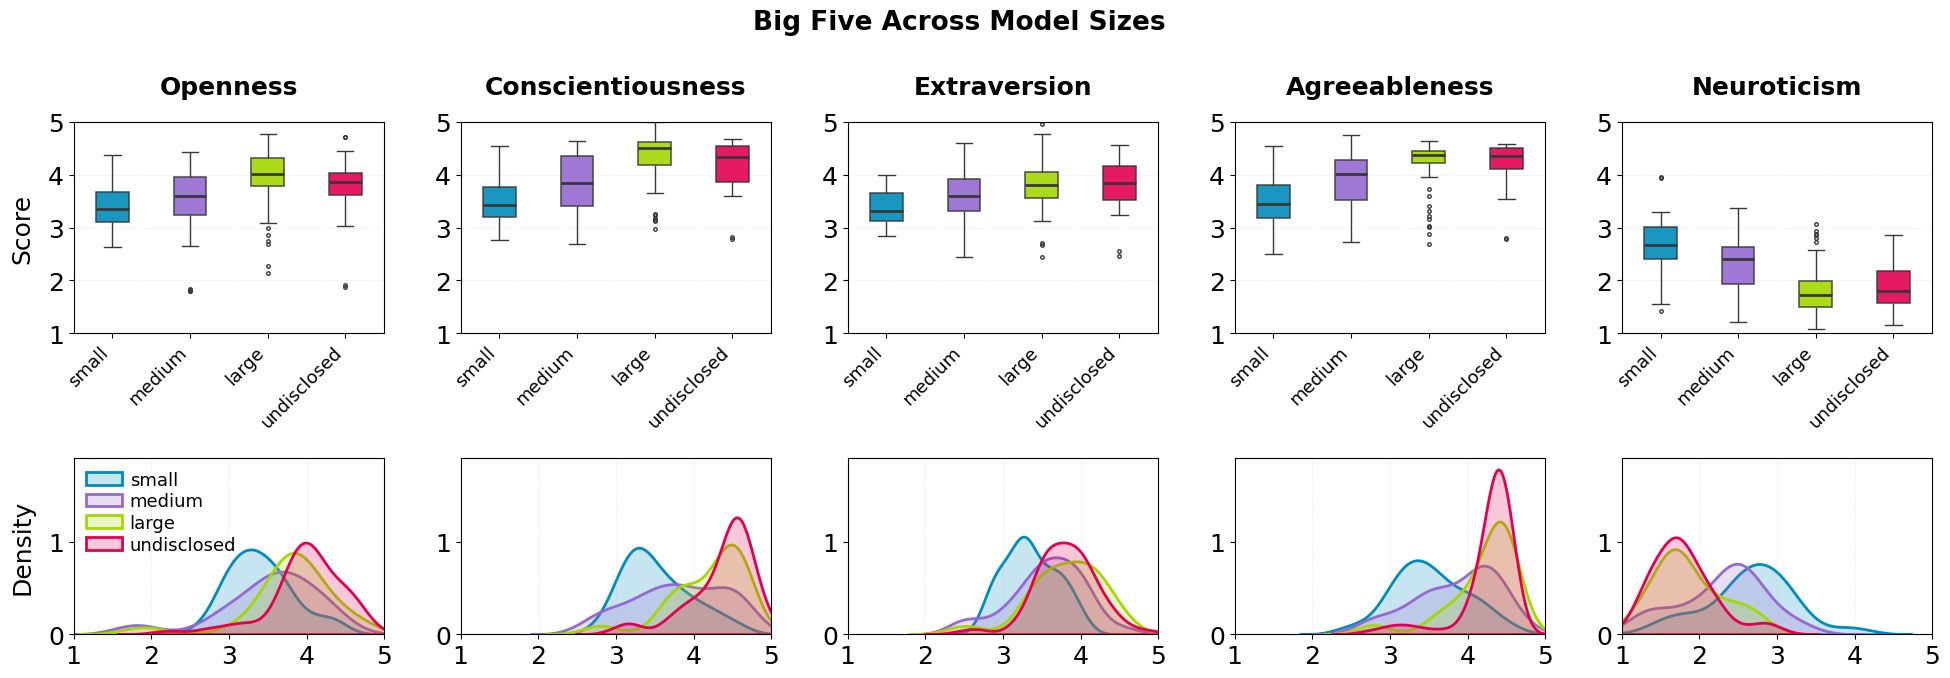

In [14]:
# Plotting
fig = plot_multigroup_comparison(
    df_sz,
    group_col="Size",
    title="Big Five Across Model Sizes",
    palette=IMPACT_SIX,
    order=["small", "medium", "large", "undisclosed"],
    cols=OCEAN_COLS,
    save_path="../../doc/figs/fig_sizes.pdf",
    test=False,
    posthoc = False,
)
plt.show()

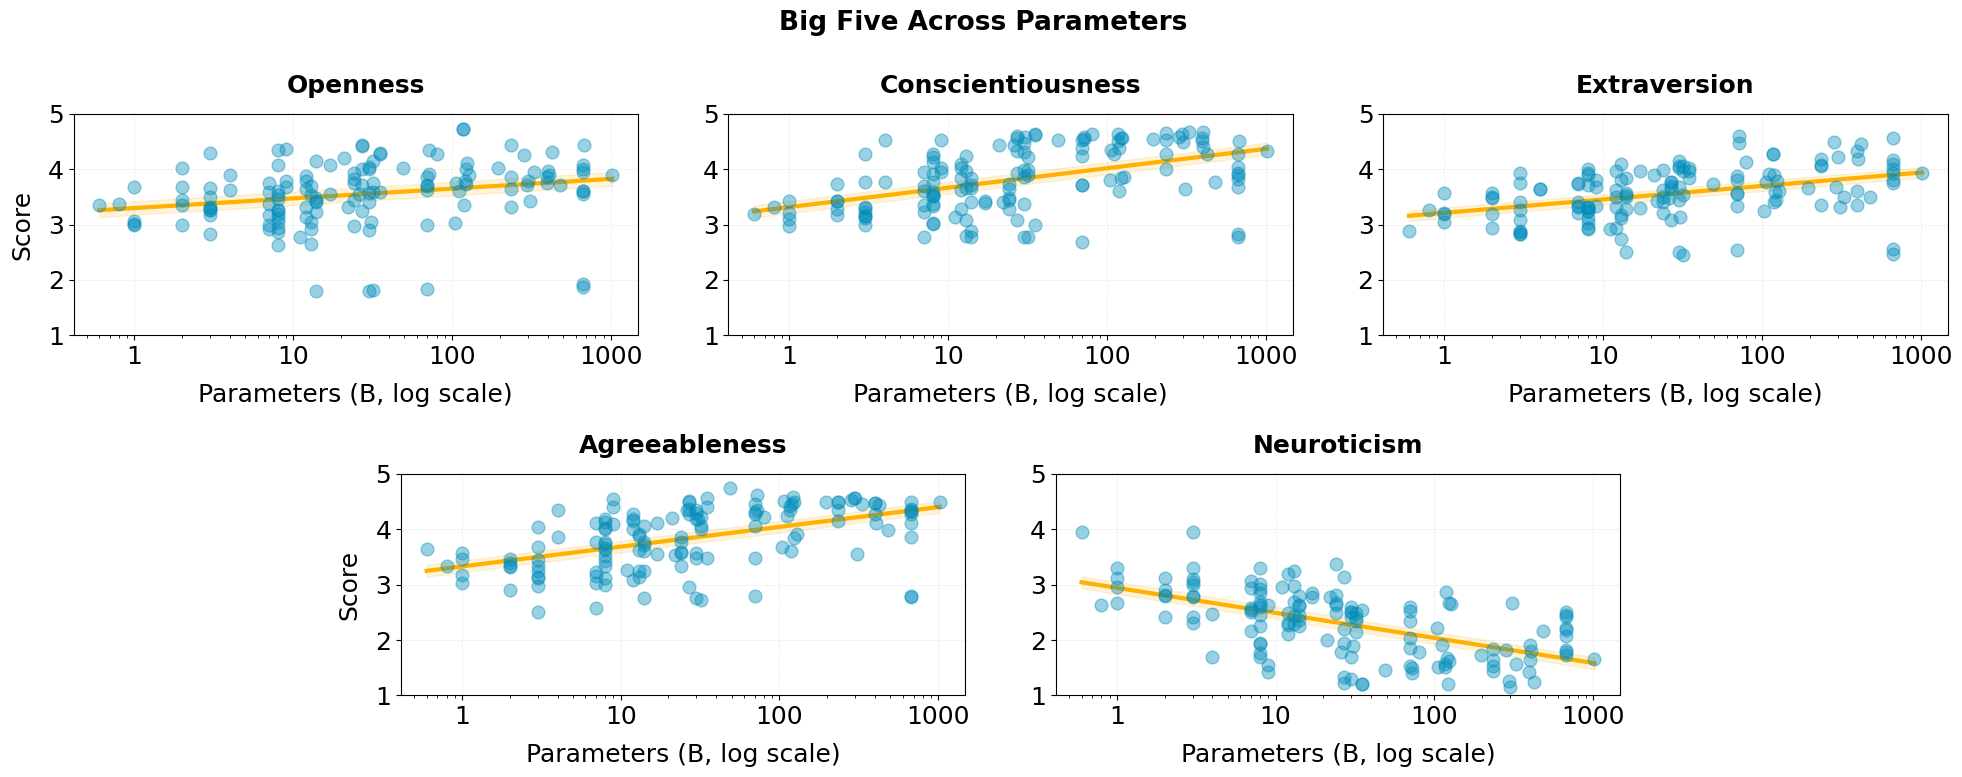

In [15]:
# Size regression plot
fig = plot_regression(
    df=df_metadata,
    x_type="param_scale",
    params_col="Parameters_B",
    palette=BINARY_PAL_BLUE_ORANGE,
    figsize=(4 * len(OCEAN_COLS), 8),
    cols=OCEAN_COLS,
    title="Big Five Across Parameters",
    save_path="../../doc/figs/fig_size_regression.pdf",
    test=False
)
plt.show()

## Release Date

In [16]:
# Release date
ref = pd.Timestamp("2026-05-12")
df_metadata["release_dt"]     = pd.to_datetime(df_metadata["Release_date"], errors="coerce")
df_metadata["release_months"] = (df_metadata["release_dt"] - ref).dt.days / 30.44
df_rel = df_metadata.dropna(subset=["release_dt", "release_months"] + OCEAN_COLS)

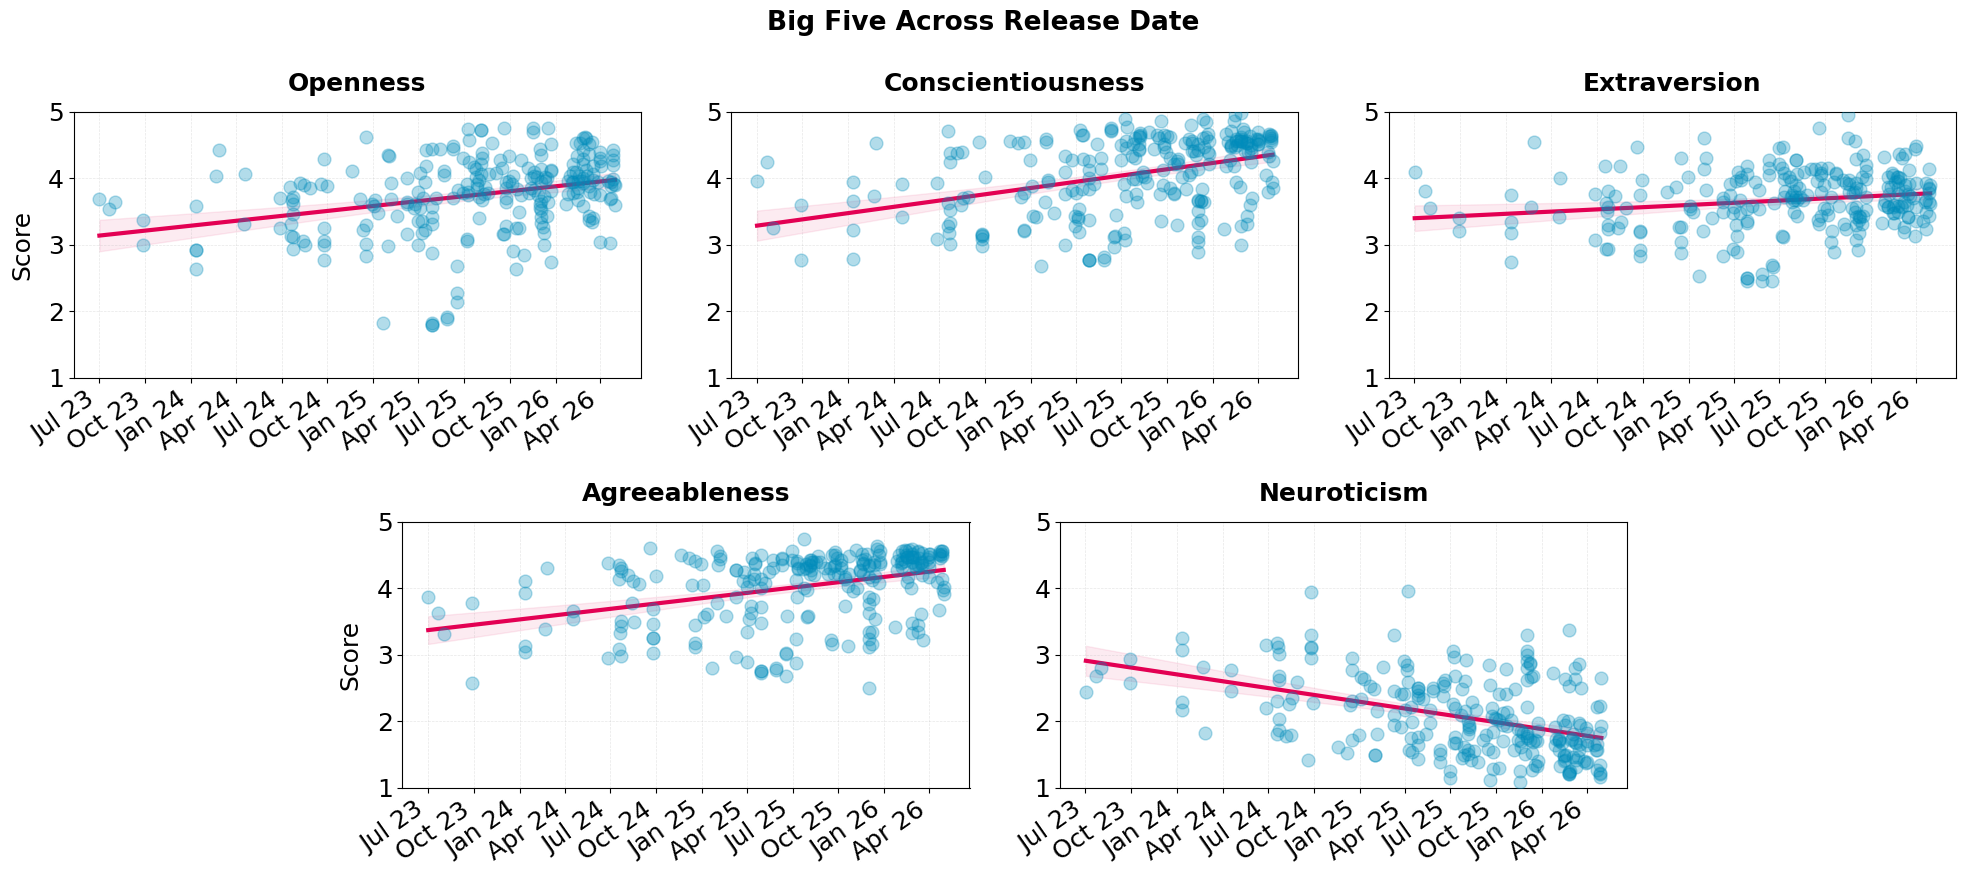

In [17]:
# Plotting
fig = plot_regression(
    df=df_rel,
    x_type="release_date",
    date_col="release_dt",
    release_months_col="release_months",
    palette=BINARY_PAL_BLUE_PINK,
    figsize=(4 * len(OCEAN_COLS), 9),
    cols=OCEAN_COLS,
    title="Big Five Across Release Date",
    save_path="../../doc/figs/fig_release_date.pdf",
    test=False
)
plt.show()

## Open-weight vs Proprietary

In [18]:
# Open-weight vs proprietary
df_lic    = df_metadata.dropna(subset=["license_group"] + OCEAN_COLS)
stats_lic = bonferroni_ttest(df_lic, "license_group", cols=OCEAN_COLS)

print(stats_lic.to_string(index=False))
print_group_stats(df_lic, "license_group")

            trait      group1      group2      t  p_bonferroni sig
         Openness open-weight proprietary -6.308        0.0000 ***
Conscientiousness open-weight proprietary -8.484        0.0000 ***
     Extraversion open-weight proprietary -4.405        0.0001 ***
    Agreeableness open-weight proprietary -7.054        0.0000 ***
      Neuroticism open-weight proprietary  7.720        0.0000 ***

───────────────────────────────────────────────────────
Mean & SD by license_group
───────────────────────────────────────────────────────

  [open-weight]  n=138
    Openness                 : mean=3.556  sd=0.576
    Conscientiousness        : mean=3.824  sd=0.569
    Extraversion             : mean=3.564  sd=0.465
    Agreeableness            : mean=3.842  sd=0.551
    Neuroticism              : mean=2.291  sd=0.605

  [proprietary]  n=109
    Openness                 : mean=3.984  sd=0.490
    Conscientiousness        : mean=4.359  sd=0.421
    Extraversion             : mean=3.807  sd=

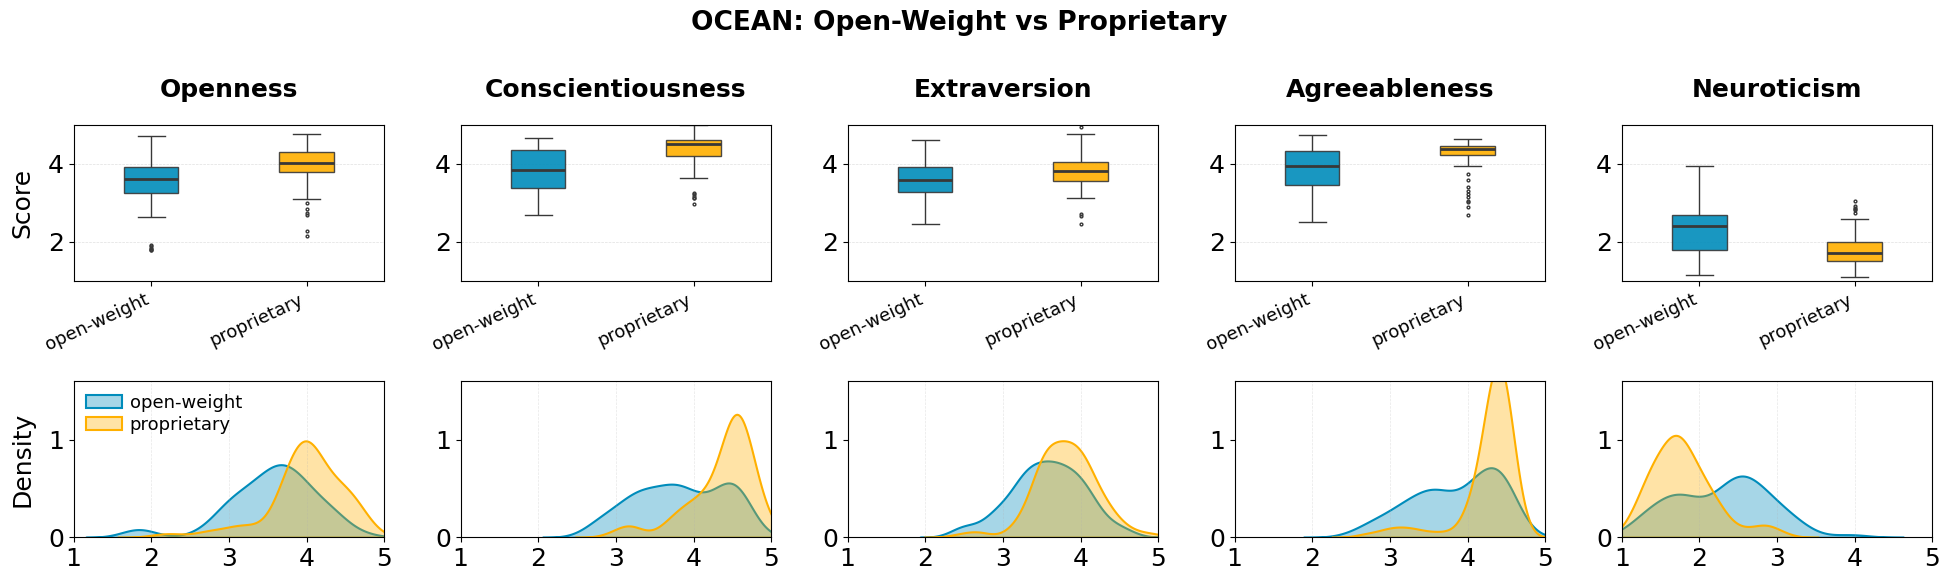

In [19]:
# Plotting
fig = plot_binary_comparison(
    df_lic,
    group_col="license_group",
    title="OCEAN: Open-Weight vs Proprietary",
    palette=BINARY_PAL_BLUE_ORANGE,
    order=["open-weight", "proprietary"],
    stats_df=stats_lic,
    cols=OCEAN_COLS,
    save_path="../../doc/figs/fig_proprietary_openweight.pdf",
    t_test = False
)
plt.show()

## Trait Correlations (from 5-factor solution CFA)

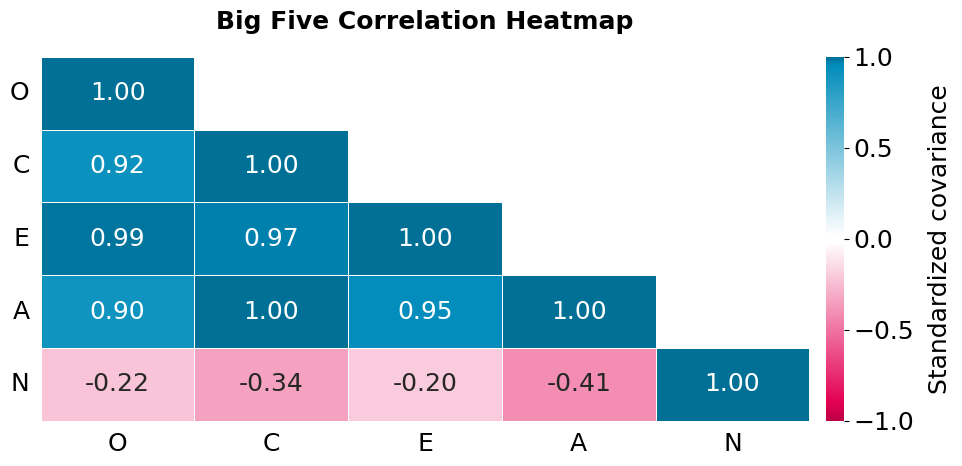

In [20]:
# Covariance heatmap from CFA
cov_vals = {
    ("Extraversion", "Agreeableness"): 0.952,
    ("Extraversion", "Conscientiousness"): 0.974,
    ("Extraversion", "Neuroticism"): -0.198,
    ("Extraversion", "Openness"): 0.986,

    ("Agreeableness", "Conscientiousness"): 0.998,
    ("Agreeableness", "Neuroticism"): -0.407,
    ("Agreeableness", "Openness"): 0.904,

    ("Conscientiousness", "Neuroticism"): -0.338,
    ("Conscientiousness", "Openness"): 0.919,

    ("Neuroticism", "Openness"): -0.221,
}

fig = plot_trait_covariances(
    cov_vals,
    title="Big Five Correlation Heatmap",
    save_path="../../doc/figs/fig_covariance_heatmap.pdf"
)